### Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('../../data/preproccedData/Augmented_PreProccedPhysicalActivityParameters.csv')

In [3]:
df.head()

,Age,Gender,Height,Weight,EnergyLevels,Physical_Activity,Sitting_Time,Cardiovascular_Health,Muscle_Strength,Flexibility,Balance,Thirsty,Pain_or_Discomfort,Available_Time,BMI,DiabetesRisk,PhysicalActivityRisk
0,24,1,165.42,52.71,2,2,1,0,0,0,0,2,0,53,16.81,29.69,73.42
1,24,1,163.45,57.96,3,1,1,1,0,1,1,1,1,128,18.94,31.04,44.06
2,28,0,151.55,50.58,4,2,1,0,1,1,1,2,0,319,19.21,28.55,14.70
3,24,0,161.46,59.03,2,3,1,1,0,1,1,5,0,128,19.75,36.28,44.05
4,22,0,152.57,48.48,3,3,0,0,1,0,1,3,0,192,18.18,24.35,14.68


In [4]:
X = df.drop(columns=['PhysicalActivityRisk'],axis=1)

In [5]:
X.head()

,Age,Gender,Height,Weight,EnergyLevels,Physical_Activity,Sitting_Time,Cardiovascular_Health,Muscle_Strength,Flexibility,Balance,Thirsty,Pain_or_Discomfort,Available_Time,BMI,DiabetesRisk
0,24,1,165.42,52.71,2,2,1,0,0,0,0,2,0,53,16.81,29.69
1,24,1,163.45,57.96,3,1,1,1,0,1,1,1,1,128,18.94,31.04
2,28,0,151.55,50.58,4,2,1,0,1,1,1,2,0,319,19.21,28.55
3,24,0,161.46,59.03,2,3,1,1,0,1,1,5,0,128,19.75,36.28
4,22,0,152.57,48.48,3,3,0,0,1,0,1,3,0,192,18.18,24.35


In [6]:
y = df['PhysicalActivityRisk']

In [7]:
y

0       73.42
1       44.06
2       14.70
3       44.05
4       14.68
        ...  
2053    52.82
2054    39.63
2055    26.41
2056    26.40
2057    26.40
Name: PhysicalActivityRisk, Length: 2058, dtype: float64

In [8]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [9]:
X = preprocessor.fit_transform(X)

In [10]:
df

,Age,Gender,Height,Weight,EnergyLevels,Physical_Activity,Sitting_Time,Cardiovascular_Health,Muscle_Strength,Flexibility,Balance,Thirsty,Pain_or_Discomfort,Available_Time,BMI,DiabetesRisk,PhysicalActivityRisk
0,24,1,165.42,52.71,2,2,1,0,0,0,0,2,0,53,16.81,29.69,73.42
1,24,1,163.45,57.96,3,1,1,1,0,1,1,1,1,128,18.94,31.04,44.06
2,28,0,151.55,50.58,4,2,1,0,1,1,1,2,0,319,19.21,28.55,14.70
3,24,0,161.46,59.03,2,3,1,1,0,1,1,5,0,128,19.75,36.28,44.05
4,22,0,152.57,48.48,3,3,0,0,1,0,1,3,0,192,18.18,24.35,14.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,48,0,160.53,112.84,5,2,0,1,0,1,0,2,0,104,41.07,67.35,52.82
2054,41,0,185.60,119.33,5,4,0,0,1,0,0,4,1,42,32.53,73.86,39.63
2055,44,1,176.58,98.71,4,1,1,1,1,1,1,1,0,125,29.72,59.81,26.41
2056,42,1,178.57,92.54,4,1,1,0,1,1,1,3,0,21,27.23,51.86,26.40


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((1646, 16), (412, 16))

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Define the preprocessing for numerical and categorical features
numerical_features = ['Age', 'Height', 'Weight', 'EnergyLevels', 'Physical_Activity', 'Sitting_Time','Cardiovascular_Health','Muscle_Strength','Flexibility','Balance','Thirsty','Pain_or_Discomfort','Available_Time']
categorical_features = ['Gender', ]

# Create a numerical transformer (standardize and impute missing values)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with the median
    ('scaler', StandardScaler())  # Scale numerical features
])

# Create a categorical transformer (encode and impute missing values)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with the most frequent category
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Encode categorical variables
])

# Combine both transformations in a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Apply the transformations
X_transformed = preprocessor.fit_transform(df)


In [13]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming evaluate_model() function is defined as:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "MLPRegressor": MLPRegressor(max_iter=500),  # Increasing max_iter for convergence
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
}

model_list = []
r2_list_train = []
r2_list_test = []

# Split the data (assuming X and y are your features and target variables)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    # Print model performance
    print(f"Model performance for {model_name} (Training set):")
    print(f"- RMSE: {model_train_rmse:.4f}")
    print(f"- MAE: {model_train_mae:.4f}")
    print(f"- R2: {model_train_r2:.4f}")
    print("-" * 40)
    
    print(f"Model performance for {model_name} (Test set):")
    print(f"- RMSE: {model_test_rmse:.4f}")
    print(f"- MAE: {model_test_mae:.4f}")
    print(f"- R2: {model_test_r2:.4f}")
    print("=" * 40)
    
    # Store model performance
    model_list.append(model_name)
    r2_list_train.append(model_train_r2)
    r2_list_test.append(model_test_r2)

# Create a DataFrame for comparison (optional)
import pandas as pd
model_performance_df = pd.DataFrame({
    'Model': model_list,
    'Train R2': r2_list_train,
    'Test R2': r2_list_test
})

print(model_performance_df)


Training MLPRegressor...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_erro

Model performance for MLPRegressor (Training set):
- RMSE: 3.2208
- MAE: 2.4045
- R2: 0.9639
----------------------------------------
Model performance for MLPRegressor (Test set):
- RMSE: 3.5910
- MAE: 2.6325
- R2: 0.9563
Training Linear Regression...
Model performance for Linear Regression (Training set):
- RMSE: 6.5440
- MAE: 5.2318
- R2: 0.8508
----------------------------------------
Model performance for Linear Regression (Test set):
- RMSE: 6.8706
- MAE: 5.5941
- R2: 0.8402
Training Lasso...
Model performance for Lasso (Training set):
- RMSE: 7.1163
- MAE: 5.5230
- R2: 0.8236
----------------------------------------
Model performance for Lasso (Test set):
- RMSE: 7.5225
- MAE: 6.0021
- R2: 0.8084
Training Ridge...
Model performance for Ridge (Training set):
- RMSE: 6.5440
- MAE: 5.2312
- R2: 0.8508
----------------------------------------
Model performance for Ridge (Test set):
- RMSE: 6.8706
- MAE: 5.5939
- R2: 0.8402
Training K-Neighbors Regressor...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

Model performance for K-Neighbors Regressor (Training set):
- RMSE: 3.5805
- MAE: 2.2358
- R2: 0.9553
----------------------------------------
Model performance for K-Neighbors Regressor (Test set):
- RMSE: 4.5220
- MAE: 2.9310
- R2: 0.9308
Training Decision Tree...
Model performance for Decision Tree (Training set):
- RMSE: 0.0006
- MAE: 0.0000
- R2: 1.0000
----------------------------------------
Model performance for Decision Tree (Test set):
- RMSE: 2.0881
- MAE: 0.9193
- R2: 0.9852
Training Random Forest Regressor...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

Model performance for Random Forest Regressor (Training set):
- RMSE: 0.7506
- MAE: 0.4655
- R2: 0.9980
----------------------------------------
Model performance for Random Forest Regressor (Test set):
- RMSE: 1.9453
- MAE: 1.1976
- R2: 0.9872
Training XGBRegressor...
Model performance for XGBRegressor (Training set):
- RMSE: 0.1219
- MAE: 0.0816
- R2: 0.9999
----------------------------------------
Model performance for XGBRegressor (Test set):
- RMSE: 1.3828
- MAE: 0.7390
- R2: 0.9935
Training CatBoosting Regressor...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model performance for CatBoosting Regressor (Training set):
- RMSE: 0.5887
- MAE: 0.4020
- R2: 0.9988
----------------------------------------
Model performance for CatBoosting Regressor (Test set):
- RMSE: 1.3667
- MAE: 0.8360
- R2: 0.9937
Training AdaBoost Regressor...
Model performance for AdaBoost Regressor (Training set):
- RMSE: 5.8220
- MAE: 4.6617
- R2: 0.8819
----------------------------------------
Model performance for AdaBoost Regressor (Test set):
- RMSE: 5.9197
- MAE: 4.6464
- R2: 0.8814
                     Model  Train R2   Test R2
0             MLPRegressor  0.963865  0.956340
1        Linear Regression  0.850825  0.840180
2                    Lasso  0.823590  0.808413
3                    Ridge  0.850824  0.840178
4    K-Neighbors Regressor  0.955343  0.930769
5            Decision Tree  1.000000  0.985239
6  Random Forest Regressor  0.998038  0.987188
7             XGBRegressor  0.999948  0.993526
8    CatBoosting Regressor  0.998793  0.993676
9       AdaBoost Regres

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


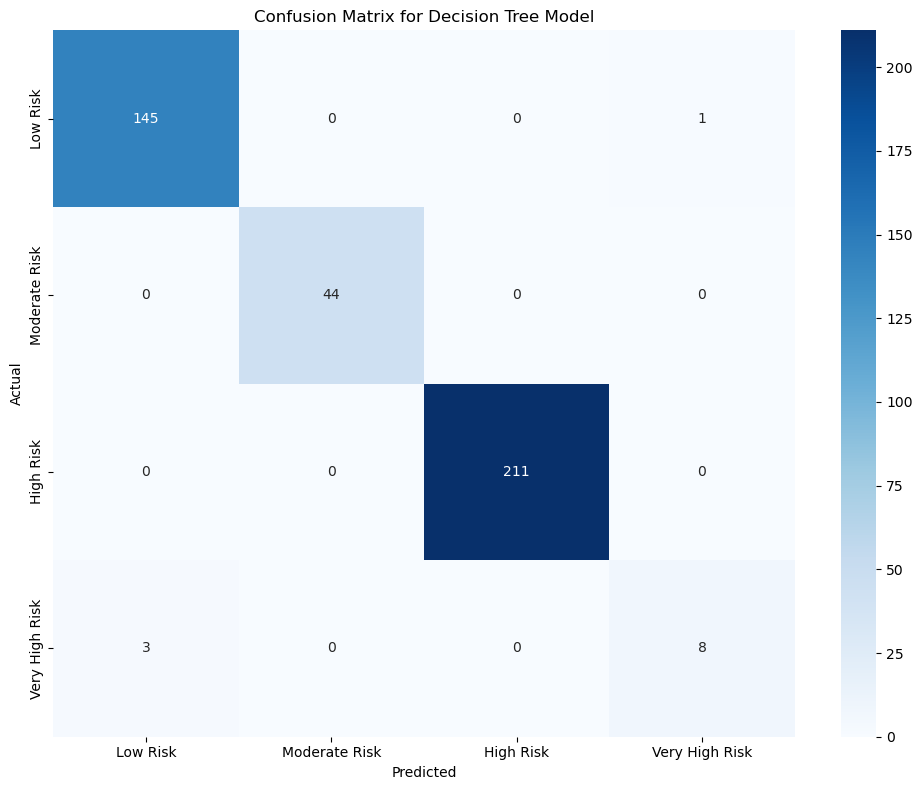


Classification Report:
                precision    recall  f1-score   support

     High Risk       0.98      0.99      0.99       146
      Low Risk       1.00      1.00      1.00        44
 Moderate Risk       1.00      1.00      1.00       211
Very High Risk       0.89      0.73      0.80        11

      accuracy                           0.99       412
     macro avg       0.97      0.93      0.95       412
  weighted avg       0.99      0.99      0.99       412



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# First, let's get predictions from the Decision Tree model
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

# Convert continuous values to discrete classes
# You can adjust these bins based on your specific risk thresholds
def categorize_risk(value):
    if value <= 25:
        return 'Low Risk'
    elif value <= 50:
        return 'Moderate Risk'
    elif value <= 75:
        return 'High Risk'
    else:
        return 'Very High Risk'

# Convert actual and predicted values to categories
y_test_cat = [categorize_risk(y) for y in y_test]
y_pred_cat = [categorize_risk(y) for y in y_pred]

# Create confusion matrix
cm = confusion_matrix(y_test_cat, y_pred_cat)

# Create labels for the plot
labels = ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, 
            yticklabels=labels)
plt.title('Confusion Matrix for Decision Tree Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_cat))